#**AGEN/BSEN 892 AI & Visual Intelligence in Smart Agriculture**
#**Week 11. Computer Vision - Segmentation**
<br/><br/>



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
! pip install torch
! pip install torchvision
! pip install monai
! pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.2 MB/s eta 0:00:00


In [4]:
import os
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
import torchvision.transforms as T
import torch

class WeedDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        # list all JPG files
        self.imgs = sorted([f for f in os.listdir(folder) if f.endswith(".jpg")])
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.folder, img_name)
        mask_path = os.path.join(self.folder, os.path.splitext(img_name)[0] + "_mask.png")

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # transforms
        if self.transform:
            image = self.transform(image)
        else:
            image = T.ToTensor()(image)

        mask = np.array(mask)
        mask = torch.tensor(mask, dtype=torch.long)
        return image, mask

train_dir = "/content/drive/MyDrive/AGST 892/Week11/Weed Detection.v1i.png-mask-semantic/train"
val_dir = "/content/drive/MyDrive/AGST 892/Week11/Weed Detection.v1i.png-mask-semantic/valid"
test_dir = "/content/drive/MyDrive/AGST 892/Week11/Weed Detection.v1i.png-mask-semantic/test"

transform = T.Compose([
    T.ToTensor()
])

train_dataset = WeedDataset(train_dir, transform=transform)
val_dataset = WeedDataset(val_dir, transform=transform)
test_dataset = WeedDataset(test_dir, transform=transform)

print(f"✅ Total train images: {len(train_dataset)}")
print(f"✅ Total val images: {len(val_dataset)}")
print(f"✅ Total test images: {len(test_dataset)}")

✅ Total train images: 96
✅ Total val images: 9
✅ Total test images: 5


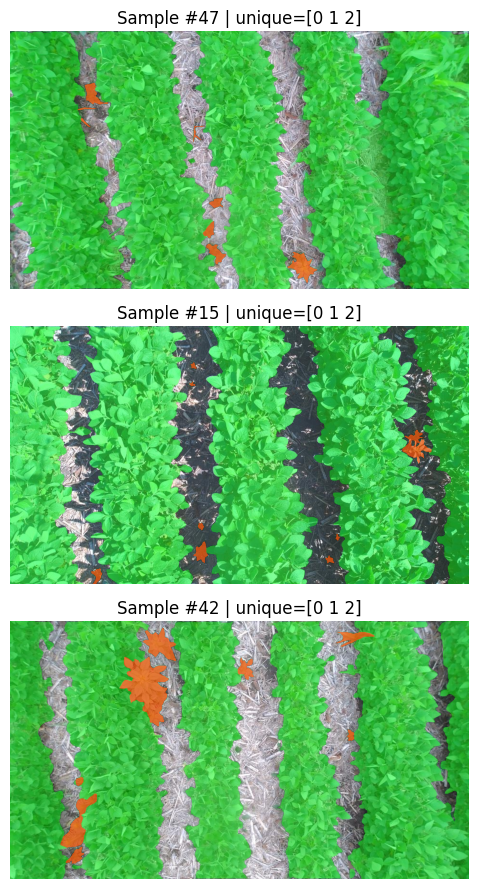

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_with_custom_colors(dataset, num_samples=3):
    # Define class colors (in RGBA) A represents the trasnparnet level (0 = fully transparent, 1 = fully opaque)
    color_map = {
        0: (0, 0, 0, 0),          # background → transparent
        1: (0, 1, 0, 0.4),        # soybean → semi-transparent green
        2: (1, 0.3, 0, 0.7),      # weed → orange-red
    }

    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(10, num_samples * 3))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_np = img.permute(1,2,0).numpy()
        mask_np = mask.numpy()

        # Create an RGBA mask overlay
        overlay = np.zeros((*mask_np.shape, 4), dtype=float)
        for cls, color in color_map.items():
            overlay[mask_np == cls] = color

        # Show image + overlay
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img_np)
        plt.imshow(overlay)
        plt.title(f"Sample #{idx} | unique={np.unique(mask_np)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage:
visualize_with_custom_colors(train_dataset, num_samples=3)

##Create your convolutional neural network

In [6]:
from transformers import SegformerForSemanticSegmentation,SegformerModel
import torch
import torch.nn as nn
import torch.nn.functional as F

class SegFormer(nn.Module):
    def __init__(self):
        super().__init__()
        self.segformerForSemanticSegmentation = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=3,
            ignore_mismatched_sizes=True)
    def forward(self, x):
        output = self.segformerForSemanticSegmentation(x)
        output = output.logits
        output = F.interpolate(output, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SegFormer().to(device)
input = torch.randn(1, 3, 128, 128).to(device)

with torch.no_grad():  # no gradients needed for inference
  output = model(input)
  print("Output shape:", output.shape)

  total_params = sum(p.numel() for p in model.parameters())
  print(f"Total parameters: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Output shape: torch.Size([1, 3, 128, 128])
Total parameters: 3,714,915


## Prepare train, validation and test function


In [9]:
from monai.losses import DiceLoss
from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassJaccardIndex
)

def train_one_epoch(model, loader, optimizer, device, num_classes):
    model.train()
    total_loss = 0.0

    crossEntropyLoss = nn.CrossEntropyLoss(weight = torch.tensor([2.0,1.0, 8.0]).cuda())
    diceLoss = DiceLoss(to_onehot_y=True,  # convert target to one-hot
                softmax=True,      # apply softmax to logits
                include_background=True,
                reduction="mean")

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)                      # [N,C,H,W]
        loss = crossEntropyLoss(logits, masks) + diceLoss(logits, masks.unsqueeze(1))
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(loader)
    return avg_loss

def validate_one_epoch(model, loader,  device, num_classes):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    # Initialize torchmetrics
    precision_metric = MulticlassPrecision(num_classes=num_classes, average='macro').to(device)
    recall_metric = MulticlassRecall(num_classes=num_classes, average='macro').to(device)
    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    iou_metric = MulticlassJaccardIndex(num_classes=num_classes, average='macro').to(device)

    crossEntropyLoss = nn.CrossEntropyLoss(weight = torch.tensor([2.0,1.0, 8.0]).cuda())
    diceLoss = DiceLoss(to_onehot_y=True,  # convert target to one-hot
                softmax=True,      # apply softmax to logits
                include_background=True,
                reduction="mean")
    with torch.no_grad():
      for imgs, masks in loader:
          imgs, masks = imgs.to(device), masks.to(device)
          logits = model(imgs)
          loss = crossEntropyLoss(logits, masks) + diceLoss(logits, masks.unsqueeze(1))
          total_loss += loss.item()

          preds = torch.argmax(logits, dim=1)

          # Save predictions and targets for metric computation
          all_preds.append(preds.view(-1))
          all_targets.append(masks.view(-1))

    # Stack all predictions and targets
    all_preds = torch.cat(all_preds).to(device)
    all_targets = torch.cat(all_targets).to(device)

    avg_loss = total_loss / len(loader)
    precision = precision_metric(all_preds, all_targets).item()
    recall = recall_metric(all_preds, all_targets).item()
    f1 = f1_metric(all_preds, all_targets).item()
    iou = iou_metric(all_preds, all_targets).item()

    return {
        "loss": avg_loss,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }


## Main code block to prepare data, train, validate, test the model and visualize the training curve

Deep learing models typically do not process one sample at a time. Data is processed in batches to improve computational efficiency and convergence speed during training.

**DataLoader** handles batching via batch_size parameter. It is designed to work with Pytorch datasets, which must return tensors.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ---- model / loss / opt ----
num_classes = 3  # background, soybean, weed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegFormer().to(device)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=1, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, num_workers=1, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=1, pin_memory=True)

# If background dominates heavily, consider class weights here.
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ---- train loop with early stopping on val loss ----
best_val_loss = float("inf")
patience, no_improve = 50, 0
epochs = 300

train_history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_iou": []
}
for epoch in range(1, epochs + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, device, num_classes)
    val_metrics = validate_one_epoch(model, val_loader, device, num_classes)

    print(f"Epoch {epoch} | "
          f"Train Loss: {tr_loss:.4f} || "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Precision: {val_metrics['precision']:.4f} | "
          f"Recall: {val_metrics['recall']:.4f} | "
          f"F1: {val_metrics['f1']:.4f} | "
          f"IoU: {val_metrics['iou']:.4f}")

    # ✅ Record metrics for plotting
    train_history["epoch"].append(epoch)
    train_history["train_loss"].append(tr_loss)
    train_history["val_loss"].append(val_metrics['loss'])
    train_history["val_precision"].append(val_metrics['precision'])
    train_history["val_recall"].append(val_metrics['recall'])
    train_history["val_f1"].append(val_metrics['f1'])
    train_history["val_iou"].append(val_metrics['iou'])

    # Use correct val loss from metrics
    val_loss = val_metrics['loss']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, 'best_model.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("⏹️ Early stopping triggered.")
            break

# load best
model.load_state_dict(best_state)
model.to(device)

# Evaluate on test set
test_metrics = validate_one_epoch(model, test_loader, device, num_classes)

# Print test metrics
print(f"Test Loss: {test_metrics['loss']:.4f} | "
      f"Precision: {test_metrics['precision']:.4f} | "
      f"Recall: {test_metrics['recall']:.4f} | "
      f"F1: {test_metrics['f1']:.4f} | "
      f"IoU: {test_metrics['iou']:.4f}")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 | Train Loss: 1.7328 || Val Loss: 1.5887 | Precision: 0.5169 | Recall: 0.6072 | F1: 0.5461 | IoU: 0.4672
Epoch 2 | Train Loss: 1.5037 || Val Loss: 1.3734 | Precision: 0.7754 | Recall: 0.6230 | F1: 0.5788 | IoU: 0.5110
Epoch 3 | Train Loss: 1.3801 || Val Loss: 1.2301 | Precision: 0.7310 | Recall: 0.6309 | F1: 0.5967 | IoU: 0.5252
Epoch 4 | Train Loss: 1.2798 || Val Loss: 1.1066 | Precision: 0.7573 | Recall: 0.6479 | F1: 0.6392 | IoU: 0.5616
Epoch 5 | Train Loss: 1.1806 || Val Loss: 1.0267 | Precision: 0.7801 | Recall: 0.7042 | F1: 0.7095 | IoU: 0.6056
Epoch 6 | Train Loss: 1.0859 || Val Loss: 0.9375 | Precision: 0.8115 | Recall: 0.7623 | F1: 0.7748 | IoU: 0.6653
Epoch 7 | Train Loss: 1.0090 || Val Loss: 0.8902 | Precision: 0.8002 | Recall: 0.8228 | F1: 0.8088 | IoU: 0.6979
Epoch 8 | Train Loss: 0.9258 || Val Loss: 0.8473 | Precision: 0.7916 | Recall: 0.8448 | F1: 0.8145 | IoU: 0.7032
Epoch 9 | Train Loss: 0.8919 || Val Loss: 0.7884 | Precision: 0.7578 | Recall: 0.8784 | F1: 0.80

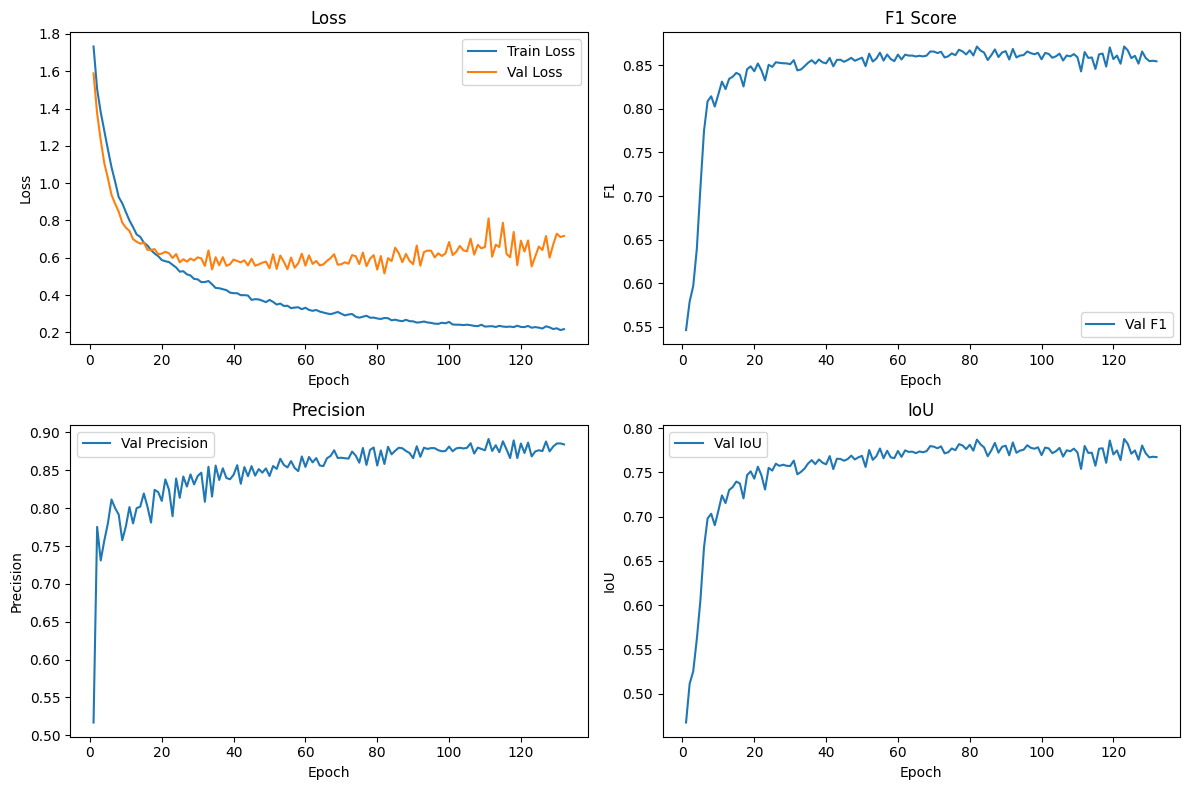

In [11]:
import matplotlib.pyplot as plt

epochs_range = train_history["epoch"]
plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 2, 1)
plt.plot(epochs_range, train_history["train_loss"], label='Train Loss')
plt.plot(epochs_range, train_history["val_loss"], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# F1 Score
plt.subplot(2, 2, 2)
plt.plot(epochs_range, train_history["val_f1"], label='Val F1')
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()

# Precision
plt.subplot(2, 2, 3)
plt.plot(epochs_range, train_history["val_precision"], label='Val Precision')
plt.title("Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(epochs_range, train_history["val_iou"], label='Val IoU')
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

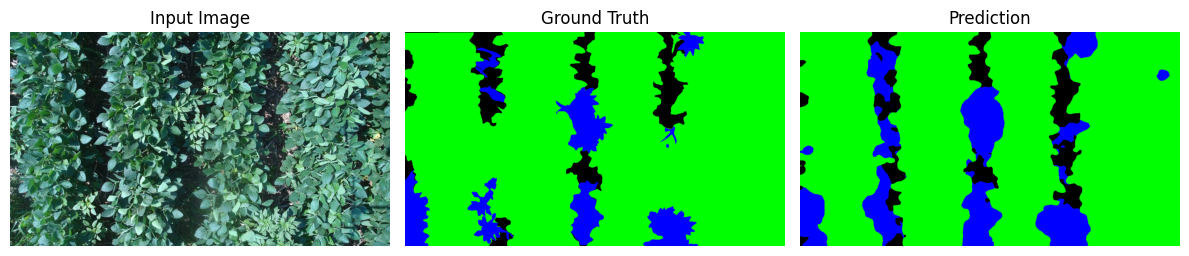

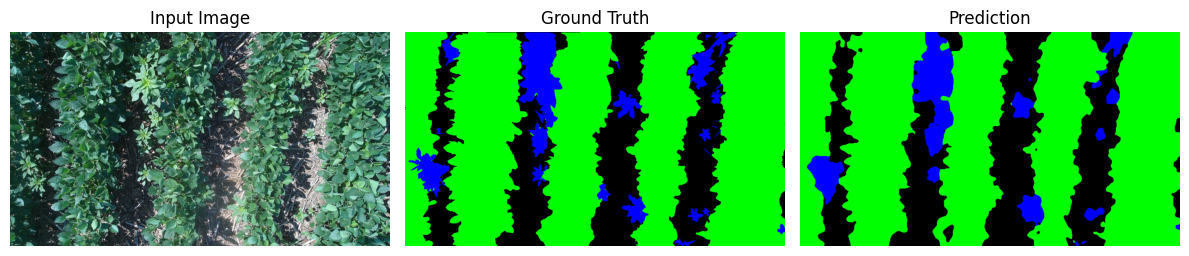

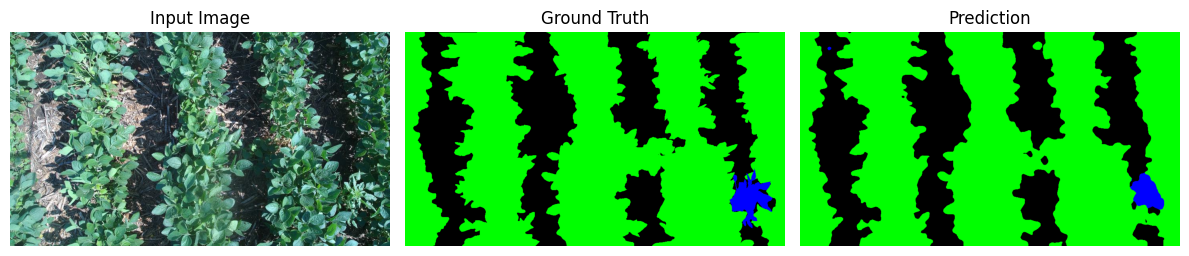

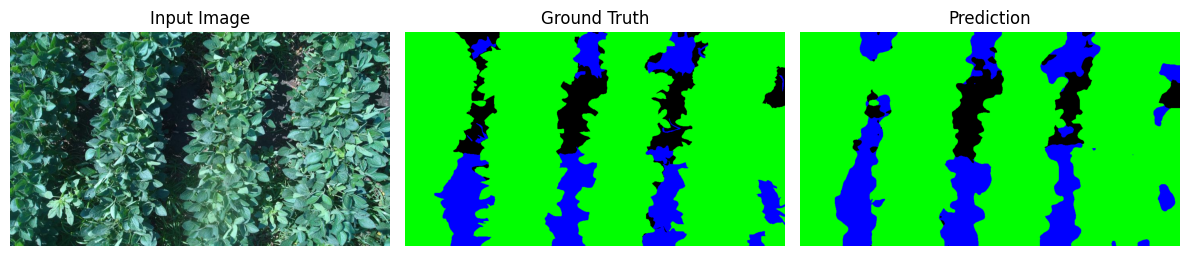

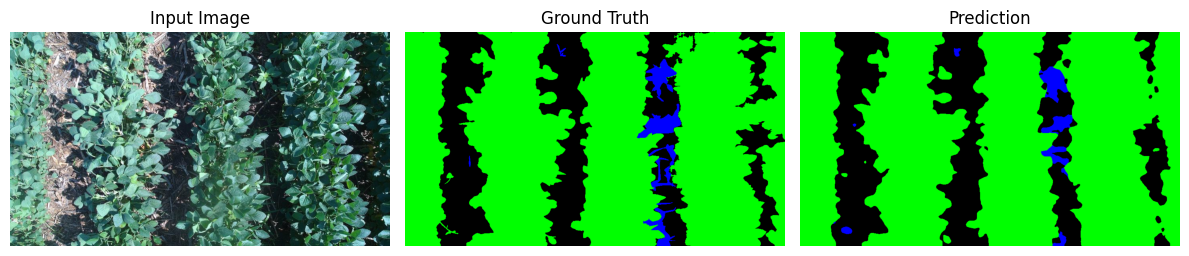

In [12]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Define a color map for your segmentation classes
# You can adjust the RGB values depending on your dataset's classes
LABEL_COLORS = {
    0: (0, 0, 0),         # Class 0 - Black (e.g., background)
    1: (0, 255, 0),       # Class 1 - Green
    2: (0, 0, 255),       # Class 2 - Blue
    # Add more if num_classes > 3
}

def decode_segmap(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for class_idx, color in LABEL_COLORS.items():
        color_mask[mask == class_idx] = color
    return color_mask

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_classes, num_samples=4):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        img, mask = dataset[idx]  # Get sample directly from Dataset
        img_tensor = img.unsqueeze(0).to(device)  # Add batch dim

        logits = model(img_tensor)           # [1, C, H, W]
        pred = torch.argmax(logits, dim=1)[0]     # [H, W]

        # Prepare data for display
        img_np = img.permute(1, 2, 0).cpu().numpy()  # [H, W, 3]
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        gt_mask = mask.cpu().numpy().astype(np.uint8)
        pred_mask = pred.cpu().numpy().astype(np.uint8)

        gt_color = decode_segmap(gt_mask)
        pred_color = decode_segmap(pred_mask)

        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_np)
        axes[0].set_title("Input Image")
        axes[0].axis("off")

        axes[1].imshow(gt_color)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        axes[2].imshow(pred_color)
        axes[2].set_title("Prediction")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

visualize_predictions(model, test_dataset, device, num_classes=3, num_samples=5)

#**Homework: Semantic Segmentation of Weeds in Soybean Fields**
We will work on a weed detection dataset in this homework. 46 digital images of weed images in a soybean field are provided in the shared Google Drive folder. Out of the total of 46 images, 44 are already labled. You are required to label the reamaining 2 assigned images and then use all 46 images for training, validation and testing. The two assigned images are also in the shared Google Drive folder.

**Goal**

* Complete the whole pipline of a semantic segmentation task using both roboflow and Colab.
* Compare the performance of the two approaches, i.e., roboflow and Colab implementations.
* Compare two different data pre-processing and/or data augmentation configurations/settings.

**Note**
* You may use AI tools to help you label.
* The training may take you around 45 minutes using A100 GPU.

**Workflow**:
1. Create a Roboflow Project in Roboflow, defining an appropriate project name and annotation class (e.g., "weed").

2. Upload Labeled Images: upload "labeled data" folder along with the coresponding annotations.json file to your project. This step will add the 44 pre-labeled images and their segmentation masks.

3. Label Assigned Images: Upload the 2 assigned images to the same Roboflow project. Click "Label myself" and label them manually or with the assistance of AI annotation tools.

4. After labeling, add all images to the dataset. Set up a custom training configuration within Roboflow. You are required to implement two trains for different data pre-processing and/or data augmentation configurations/settings.

5. Export your dataset in Semantic Segmentation Masks format to your computer and upload it to your Google Drive for use in Colab.

6. Open the provided Colab notebook. Update the file paths to point to your dataset on Google Drive. Select a semantic segmentation model and set appropriate hyperparameters. Run the notebook to train your model.

7. Write a Report about the results and metrics from both Roboflow and Colab. You need to visual examples of predictions and make a discussion comparing the performance across platforms and explaining possible reasons for success or failure for your model or your dataset.

**Submission**

Write a report (in PDF) including
* A beginning paragrph / brief summary of what you did.
* Key model performance metrics.
* Advanced Training Graphs in roboflow and the graph of loss curve in Colab. Make sure they are in appropriate sizes that texts in the graphs are readible.
* Show the model prediction results of a few test images from both approaches.
* A discussion and conclusion paragraph.Compare your two different data pre-processing and/or data augmentation configurations/settings.